# 00 -- Scientific Python and reproducible numerics

| question | answer |
|---|---|
| What physics problem? | A measurement or simulation must give the same number twice. |
| What mathematics? | Floating-point arithmetic, rounding error, and error growth. |
| What algorithm? | Vectorized evaluation and seeded pseudo-random number generation. |
| What software? | NumPy, SymPy, Pandas, Matplotlib; optional PyTorch. |
| What experiment? | Any experiment whose analysis pipeline must be reproducible. |
| What engineering application? | Deterministic firmware and DSP produce bit-identical results. |

This notebook follows the repository template: English explanation, mathematical derivation,
dimensions and SI units, SymPy derivation, NumPy implementation, Pandas tables, Matplotlib plots,
optional PyTorch, exercises, and engineering applications. It reuses the `physkit` package and the
results of earlier chapters.

In [1]:
import numpy as np, pandas as pd, sympy as sp
import matplotlib.pyplot as plt
import physkit
from physkit import constants as C, units as U, linalg as la
from physkit.plotting import use_style
use_style()
torch = physkit.optional_torch()            # None if PyTorch is unavailable; NumPy stays authoritative
sp.init_printing()
print("physkit", physkit.__version__, "| numpy", np.__version__,
      "| torch:", "present" if torch is not None else "absent (optional)")

physkit 0.1.0 | numpy 2.4.6 | torch: absent (optional)


## English explanation

Scientific computing represents real numbers with a finite number of bits, so most values are
stored approximately. A reproducible pipeline controls three things: the numeric type (how much
precision), the order of operations (rounding is not associative), and every source of randomness
(seed the generator). This chapter fixes those habits; every later chapter depends on them.

The subject-verb-object frame: the *computer stores* an approximation, the *operation accumulates*
error, and the *seed fixes* the random stream.

## Mathematical derivation

A binary floating-point number has the form $x=\pm(1+f)\,2^{e}$ with a fixed-width fraction
$f$. The gap between consecutive representable numbers near 1 is the machine epsilon
$\varepsilon$; for IEEE-754 double precision $\varepsilon=2^{-52}\approx2.22\times10^{-16}$. A single
rounding introduces relative error at most $\varepsilon/2$. Subtracting two nearly equal numbers
$a-b$ **cancels** their leading digits and amplifies that relative error by $\frac{|a|+|b|}{|a-b|}$ --
catastrophic cancellation, the main enemy of naive formulas.

## Dimensions and SI units

Floating-point values are pure numbers; physical meaning comes from the unit attached to them.
The repository keeps that meaning explicit with `physkit.units`. Below, Planck's constant times a
frequency is checked to carry the dimension of energy before any number is trusted.

In [2]:
h = U.Quantity(C.H, U.ACTION)          # J s
f = U.Quantity(4.84e14, U.FREQUENCY)   # Hz (red light)
E = h * f
E.to_dimension(U.ENERGY)               # raises if the dimensions were wrong
print("photon energy dimension:", E.dim, "| value:", E.value, "J =", E.value / C.E, "eV")

photon energy dimension: L^2 M^1 T^-2 | value: 3.2070179526e-19 J = 2.0016631653111476 eV


## SymPy derivation

SymPy computes with exact symbols, so it is the reference against which floating point is
judged. Here the associativity failure of floating-point addition is exhibited: exactly, the sum is
order-independent; in `float`, it is not.

In [3]:
a, b, c = sp.Rational(1), sp.Rational(1, 10**16), sp.Rational(-1)
exact = (a + b) + c
print("SymPy exact ((1 + 1e-16) - 1) =", exact, "=", float(exact))
fa, fb, fc = 1.0, 1e-16, -1.0
print("float  ((1 + 1e-16) - 1) =", (fa + fb) + fc, " vs (1e-16 + (1 - 1)) =", fb + (fa + fc))
print("=> floating-point addition is not associative")

SymPy exact ((1 + 1e-16) - 1) = 1/10000000000000000 = 1e-16
float  ((1 + 1e-16) - 1) = 0.0  vs (1e-16 + (1 - 1)) = 1e-16
=> floating-point addition is not associative


## NumPy implementation

NumPy evaluates array expressions in compiled loops (vectorization): the same result as a
Python loop, produced far faster and with a fixed evaluation order. We also show a numerically stable
rewrite that avoids cancellation.

In [4]:
eps = np.finfo(np.float64).eps
print("machine epsilon (float64):", eps)

# catastrophic cancellation: sqrt(1+x) - 1 for small x
x = 1e-12
naive = np.sqrt(1 + x) - 1.0
stable = x / (np.sqrt(1 + x) + 1.0)         # algebraically identical, no cancellation
print(f"naive  = {naive:.3e}")
print(f"stable = {stable:.3e}  (reference x/2 = {x/2:.3e})")

# vectorization vs a Python loop (same numbers)
v = np.linspace(0, 1, 1_000_00)
loop = sum(vi**2 for vi in v.tolist())
vect = float(np.sum(v**2))
print("loop and vectorized agree:", np.isclose(loop, vect))

machine epsilon (float64): 2.220446049250313e-16
naive  = 5.000e-13
stable = 5.000e-13  (reference x/2 = 5.000e-13)
loop and vectorized agree: True


## Pandas tables

Pandas organizes numeric facts into tables for reporting. Here: the precision of each common
NumPy float type.

In [5]:
rows = []
for dt in (np.float16, np.float32, np.float64):
    fi = np.finfo(dt)
    rows.append({"dtype": np.dtype(dt).name, "bits": fi.bits, "eps": fi.eps,
                 "max": fi.max, "decimal_digits": fi.precision})
df = pd.DataFrame(rows)
print(df.to_string(index=False))

  dtype  bits          eps           max  decimal_digits
float16    16 9.765625e-04  6.550400e+04               3
float32    32 1.192093e-07  3.402823e+38               6
float64    64 2.220446e-16 1.797693e+308              15


## Matplotlib plots

The stable and naive formulas diverge as $x\to0$. Plotting relative error against $x$ shows the
naive form losing all significant digits once cancellation dominates.

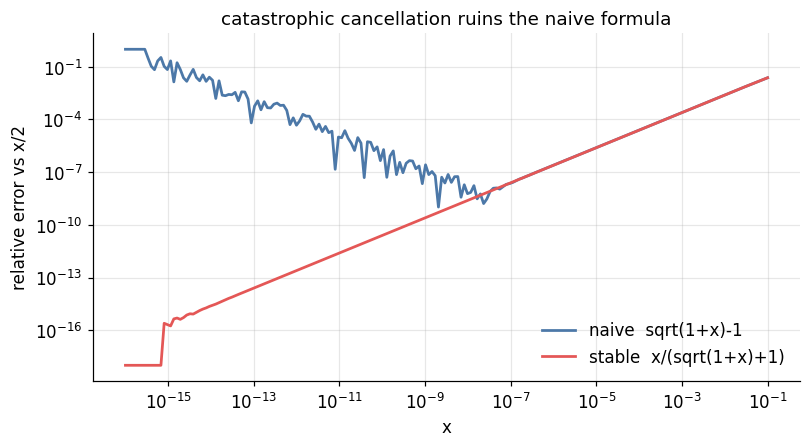

In [6]:
xs = np.logspace(-16, -1, 200)
naive = np.sqrt(1 + xs) - 1.0
stable = xs / (np.sqrt(1 + xs) + 1.0)
ref = xs / 2
plt.figure()
plt.loglog(xs, np.abs(naive - ref) / ref, label="naive  sqrt(1+x)-1")
plt.loglog(xs, np.abs(stable - ref) / ref + 1e-18, label="stable  x/(sqrt(1+x)+1)")
plt.xlabel("x"); plt.ylabel("relative error vs x/2")
plt.title("catastrophic cancellation ruins the naive formula")
plt.legend(); plt.tight_layout(); plt.show()

## PyTorch (optional)

When PyTorch is installed it provides the same arithmetic on tensors (and on a GPU). The NumPy
result stays authoritative; PyTorch is a cross-check. The cell is guarded so the notebook runs
without it.

In [7]:
if torch is not None:
    xt = torch.linspace(0, 1, 1000, dtype=torch.float64)
    print("torch sum(x^2) =", float((xt**2).sum()),
          "| numpy =", float(np.sum(np.linspace(0,1,1000)**2)))
else:
    print("PyTorch absent -- NumPy path already computed the result above.")

PyTorch absent -- NumPy path already computed the result above.


## Exercises

1. Show numerically that `0.1 + 0.2 == 0.3` is `False` in float64, and explain why using the
   binary expansion of `0.1`.
2. The quadratic formula loses precision for one root when $b^2\gg4ac$. Implement the stable variant
   using $x_1 x_2=c/a$ and compare.
3. Seed `np.random.default_rng` with a fixed value and confirm two runs produce identical arrays;
   remove the seed and confirm they differ. State why reproducibility needs the seed.

## Engineering applications

A **firmware** routine on a microcontroller must accumulate ADC samples in an order that avoids
cancellation, or a slowly drifting baseline will corrupt the sum. A **DSP** filter implemented in
fixed point chooses word length from the same $\varepsilon$ analysis. A **GPU** kernel that reduces
millions of values uses pairwise summation to bound error growth. Reproducibility -- fixed dtype,
fixed order, fixed seed -- is what lets an instrument's result be audited.

Summary (subject-verb-object): the computer stores approximations; the algorithm controls error; the
seed fixes randomness; the engineer guarantees reproducibility.